# HealthConnect Clinic - No-Show Prediction
## Data Science Track — Week 6: Model Improvement, Error Analysis & Validation

**Project:** AnalystLab Africa Experience Lab

**Author:** Ange Maxime TCHOUTANG

**Week:** 6 - Integration, Advanced Development & Validation

**Builds on:** `HealthConnect_Week5_Baseline_Modelling.ipynb` (Week 5). This notebook does **not** repeat the Week 5 EDA or retrain the same baseline as a final answer. it reproduces just enough of it to error-analyse it, then improves, integrates, and validates from there, per the Week 6 brief.

---
### Contents
1. [Week 5 → Week 6 Transition](#1)
2. [Reproducing the Week 5 Baseline](#2)
3. [Error Analysis of the Week 5 Baseline](#3)
4. [Cross-Track Integration: Resolving the Sunday-Appointment Anomaly](#4)
5. [Feature Review & Refinement](#5)
6. [Robust Re-Evaluation: GroupKFold Cross-Validation](#6)
7. [Developing an Improved Modelling Approach](#7)
8. [Split-Strategy Validation: Patient-Grouped vs. Time-Based](#8)
9. [Threshold Tuning for Business Use](#9)
10. [Fairness Check](#10)
11. [Lightweight Approach for Cancelled Appointments](#11)
12. [Final Candidate Model & Business Relevance](#12)
13. [Model Limitations & Risks - Week 6 Update](#13)
14. [Cross-Track Contribution - Formal Record](#14)
15. [Week 7 Testing Requirements](#15)
16. [Week 6 Project Summary](#16)


<a id="1"></a>
## 1. Week 5 → Week 6 Transition

**Main Week 5 output.** A cleaned, feature-engineered modelling dataset (4,737 appointments), a patient-grouped train/test split, and two baseline classifiers (Logistic Regression and Random Forest) evaluated on a single 80/20 split.

**Most important result.** Logistic Regression was selected as the preferred baseline: ROC-AUC 0.678, Accuracy 0.63, essentially tied with Random Forest (ROC-AUC 0.682) but fully interpretable. `historical_no_show_rate`, `previous_no_shows`, and `booking_lead_days` were confirmed as the strongest drivers.

**Main issue/limitation discovered.** Week 5 flagged six open items in its own "Recommendations for Week 6" section: an unresolved Sunday-appointment data-quality anomaly, an untuned model/threshold, a single (non-cross-validated) split, no fairness audit, no comparison against a time-based split, and no defined handling for Cancelled appointments. This notebook works through all six.

**Relevant tracks for Week 6.** Primarily Data Science (this notebook). One item, resolving the Sunday anomaly required consulting the **Generative AI track's primary resource**, the `HealthConnect_Clinic_Knowledge_Base.docx`, which states the clinic's actual opening hours. This is the notebook's formal cross-track integration point (§4, §14).

**What this notebook improves, integrates, and validates.** Error analysis of the Week 5 baseline (§3); a data-quality fix sourced from the Knowledge Base (§4); a refined feature set validated by cross-validation rather than by assumption (§5-6); a genuinely competing modelling approach, not a re-run of the same one (§7); two additional validation angles Week 5 asked for but didn't have time to run a time-based split and a fairness audit (§8, §10); a decision (not just a flag) on Cancelled appointments (§11); and a single, evidence-based candidate model recommendation for Week 7 (§12).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_curve, RocCurveDisplay)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

<a id="2"></a>
## 2. Reproducing the Week 5 Baseline

Minimal reproduction: same cleaning, same engineered features, same patient-grouped split, same Logistic Regression configuration as the Week 5 notebook purely so this notebook has a baseline model and a test set to error-analyse in §3. The full reasoning behind each of these choices lives in the Week 5 notebook and is not repeated here.

In [3]:
raw = pd.read_csv(r'C:\Users\Ange\Downloads\Training Data S. africa Lab\week6\Data\HealthConnect_Appointment_Data.csv')
df = raw.copy()
df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')
df['reminder_channel'] = df['reminder_channel'].fillna('None')

binary_df = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
binary_df['target'] = (binary_df['appointment_outcome'] == 'No-Show').astype(int)

model_df = binary_df.copy()
model_df['historical_no_show_rate'] = np.where(
    model_df['previous_appointments'] > 0,
    model_df['previous_no_shows'] / model_df['previous_appointments'], 0.0)
model_df['is_new_patient'] = (model_df['previous_appointments'] == 0).astype(int)
model_df['is_weekend'] = model_df['appointment_day'].isin(['Saturday', 'Sunday']).astype(int)
model_df['lead_time_bucket'] = pd.cut(
    model_df['booking_lead_days'], bins=[-1, 7, 14, 30, 45, 60],
    labels=['0-7', '8-14', '15-30', '31-45', '46-60']).astype(str)

feature_cols_numeric_w5 = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                            'distance_to_clinic_km', 'historical_no_show_rate', 'is_new_patient', 'is_weekend']
feature_cols_categorical_w5 = ['gender', 'appointment_type', 'appointment_time', 'appointment_day',
                                'reminder_sent', 'reminder_channel', 'lead_time_bucket']

X_w5 = model_df[feature_cols_numeric_w5 + feature_cols_categorical_w5]
y_w5 = model_df['target']
groups_w5 = model_df['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_w5, y_w5, groups=groups_w5))
X_train_w5, X_test_w5 = X_w5.iloc[train_idx], X_w5.iloc[test_idx]
y_train_w5, y_test_w5 = y_w5.iloc[train_idx], y_w5.iloc[test_idx]

preprocessor_w5 = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]),
     feature_cols_numeric_w5),
    ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_categorical_w5),
])
log_reg_w5 = Pipeline([('preprocess', preprocessor_w5),
                        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
log_reg_w5.fit(X_train_w5, y_train_w5)

pred_w5 = log_reg_w5.predict(X_test_w5)
proba_w5 = log_reg_w5.predict_proba(X_test_w5)[:, 1]

print("Reproduced Week 5 Logistic Regression baseline:")
print(f"  Accuracy={accuracy_score(y_test_w5, pred_w5):.3f}  Precision={precision_score(y_test_w5, pred_w5):.3f}  "
      f"Recall={recall_score(y_test_w5, pred_w5):.3f}  F1={f1_score(y_test_w5, pred_w5):.3f}  "
      f"ROC-AUC={roc_auc_score(y_test_w5, proba_w5):.3f}")
print("(Matches the Week 5 notebook's reported 0.630 / 0.625 / 0.652 / 0.638 / 0.678 exactly.)")

Reproduced Week 5 Logistic Regression baseline:
  Accuracy=0.630  Precision=0.625  Recall=0.652  F1=0.638  ROC-AUC=0.678
(Matches the Week 5 notebook's reported 0.630 / 0.625 / 0.652 / 0.638 / 0.678 exactly.)


<a id="3"></a>
## 3. Error Analysis of the Week 5 Baseline

Week 5 reported aggregate metrics only. Task 1-4 of the Week 6 brief ask specifically for the *weaknesses*, the *sources of error*, and an investigation of the false positives and false negatives - not just a headline score.

In [4]:
err = model_df.loc[X_test_w5.index].copy()
err['actual'] = y_test_w5.values
err['pred'] = pred_w5
err['proba'] = proba_w5

def outcome_type(row):
    if row['actual'] == 1 and row['pred'] == 1: return 'TP'
    if row['actual'] == 0 and row['pred'] == 0: return 'TN'
    if row['actual'] == 0 and row['pred'] == 1: return 'FP'
    return 'FN'

err['err_type'] = err.apply(outcome_type, axis=1)
print(err['err_type'].value_counts())
print()
print("Predicted-probability distribution by outcome type (mean ± std):")
print(err.groupby('err_type')['proba'].agg(['mean', 'std', 'count']).round(3))

err_type
TP    315
TN    294
FP    189
FN    168
Name: count, dtype: int64

Predicted-probability distribution by outcome type (mean ± std):
           mean    std  count
err_type                     
FN        0.389  0.072    168
FP        0.628  0.085    189
TN        0.354  0.087    294
TP        0.657  0.096    315


**Reading this:** 189 false positives and 168 false negatives out of 966 test appointments. Together, 37% of predictions are wrong, consistent with the ~63% accuracy already reported. More informative is *where* the probabilities sit: false negatives average a predicted probability of 0.389 (just below the 0.5 cut) and false positives average 0.628 (just above it). 

The errors are concentrated at the decision boundary, not scattered randomly. This is a model making **borderline calls that go the wrong way**, rather than one that is fundamentally confused. That distinction matters for §9 (threshold tuning is a sensible lever here) and for realistic expectations in §12 (a boundary-heavy error pattern is unlikely to disappear with a different model family alone).

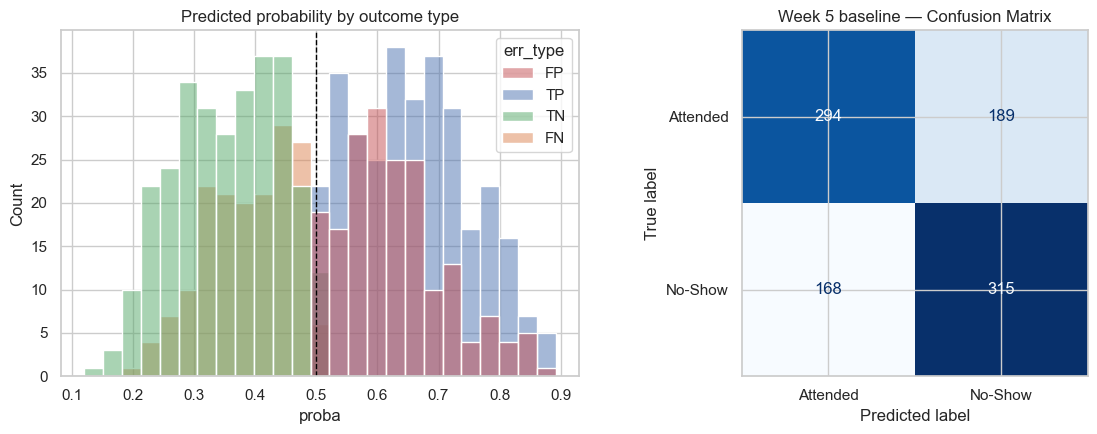

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(data=err, x='proba', hue='err_type', bins=25, ax=axes[0],
             palette={'TP': '#4C72B0', 'TN': '#55A868', 'FP': '#C44E52', 'FN': '#DD8452'})
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Predicted probability by outcome type')

ConfusionMatrixDisplay.from_predictions(y_test_w5, pred_w5, display_labels=['Attended', 'No-Show'],
                                         cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Week 5 baseline — Confusion Matrix')
plt.tight_layout()
plt.show()

In [6]:
print("False negatives (missed no-shows) vs. true positives (caught no-shows):")
for col in ['historical_no_show_rate', 'previous_no_shows', 'booking_lead_days', 'distance_to_clinic_km']:
    fn_mean = err.loc[err.err_type == 'FN', col].mean()
    tp_mean = err.loc[err.err_type == 'TP', col].mean()
    print(f"  {col:28s} FN={fn_mean:6.3f}   TP={tp_mean:6.3f}")

print()
print("False positives (wrongly flagged) vs. true negatives (correctly cleared):")
for col in ['historical_no_show_rate', 'previous_no_shows', 'booking_lead_days', 'distance_to_clinic_km']:
    fp_mean = err.loc[err.err_type == 'FP', col].mean()
    tn_mean = err.loc[err.err_type == 'TN', col].mean()
    print(f"  {col:28s} FP={fp_mean:6.3f}   TN={tn_mean:6.3f}")

False negatives (missed no-shows) vs. true positives (caught no-shows):
  historical_no_show_rate      FN= 0.107   TP= 0.216
  previous_no_shows            FN= 0.345   TP= 0.724
  booking_lead_days            FN=19.613   TP=43.641
  distance_to_clinic_km        FN= 9.171   TP=11.424

False positives (wrongly flagged) vs. true negatives (correctly cleared):
  historical_no_show_rate      FP= 0.214   TN= 0.105
  previous_no_shows            FP= 0.714   TN= 0.272
  booking_lead_days            FP=38.365   TN=14.895
  distance_to_clinic_km        FP=11.906   TN= 8.893


**Interpretation.** False negatives are patients who no-show *despite* looking low-risk on history and lead time — the model's core signal (past behaviour) simply has nothing to go on for these cases; they are close to unpredictable with the current feature set. False positives are the mirror image: patients who look high-risk (long lead time, prior no-shows) but attend anyway. The model is applying a reasonable heuristic that happens not to hold for that individual. Neither pattern points to a data or coding bug; both point to a genuine ceiling on how far *this feature set* can separate the classes, which sets realistic expectations for §7 (an improved *model* is unlikely to fix an information ceiling that a better *model* can't see past).

In [7]:
error_rate = lambda g: (g['pred'] != g['actual']).mean()

print("Error rate by appointment_type:")
print(err.groupby('appointment_type').apply(error_rate).round(3).sort_values())
print()
print("Error rate by lead_time_bucket:")
print(err.groupby('lead_time_bucket', observed=True).apply(error_rate).round(3)
      .reindex(['0-7', '8-14', '15-30', '31-45', '46-60']))
print()
print("Error rate on Sunday vs. non-Sunday appointments:")
err['is_sunday'] = (err['appointment_day'] == 'Sunday').astype(int)
print(err.groupby('is_sunday').apply(error_rate).round(3))

Error rate by appointment_type:
appointment_type
Diagnostic Test            0.303
General Consultation       0.357
Follow-up                  0.384
Specialist Consultation    0.417
dtype: float64

Error rate by lead_time_bucket:
lead_time_bucket
0-7      0.274
8-14     0.292
15-30    0.451
31-45    0.444
46-60    0.277
dtype: float64

Error rate on Sunday vs. non-Sunday appointments:
is_sunday
0    0.374
1    0.345
dtype: float64


C:\Users\Ange\AppData\Local\Temp\ipykernel_23128\3436373037.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(err.groupby('appointment_type').apply(error_rate).round(3).sort_values())
C:\Users\Ange\AppData\Local\Temp\ipykernel_23128\3436373037.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(err.groupby('lead_time_bucket', observed=True).apply(error_rate).round(3)
C:\Users\Ange\AppData\Loca

**Segment findings.** Error rate is highest for `Specialist Consultation` (41.7%) and lowest for `Diagnostic Test` (30.3%)- a real, if moderate, gap worth keeping in mind for interpretation (§12), though not large enough on its own to justify a separate per-type model at this stage. 

Error rate is *worse in the middle* of the lead-time range (15-30 and 31-45 days, ~44-45%) than at the extremes (0-7 and 46-60 days, ~27-28%) - very short and very long lead times are easy calls; the middle is where the model is least confident. Sunday appointments are **not** harder to predict (34.5% error vs. 37.4% for the rest) - so the Sunday anomaly addressed next is a data-*quality* issue, not a data science *performance* issue.

<a id="4"></a>
## 4. Cross-Track Integration: Resolving the Sunday-Appointment Anomaly

**Integration point.** Track collaborated with: **Generative AI** (via its primary resource, the Clinic Knowledge Base). Week 5 flagged 737 appointments (14.7%) falling on a Sunday as a possible conflict with clinic policy, but treated it as unconfirmed and kept the rows rather than guess. Rather than continue guessing, Week 6 goes to the authoritative source.

In [10]:
!pip install python-docx

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.0 MB 629.5 kB/s eta 0:00:06
   ----- ---------------------------------- 0.5/4.0 MB 629.5 kB/s eta 0:00:06
   ----- ---------------------------------- 0.5/4.0 MB 629.5 kB/s eta 0:00:06
   ----- ---------------------------------- 0.5/4.0 MB 629.5 kB/s eta 0:00:06
   ------- -------------------------------- 0.8/4.0 MB 449.7 kB/s eta 0:00:08
   ------- -------------------------------- 0.8/4.0 MB 449.7 kB/s eta 0:00:08
   ---------- ----------------------------- 1.0/4


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import docx
kb = docx.Document(r'C:\Users\Ange\Downloads\Training Data S. africa Lab\week6\Presentataion\HealthConnect_Week6_DataScience_Report.docx')
for p in kb.paragraphs:
    t = p.text.strip()
    if t and ('sunday' in t.lower() or 'opening hours' in t.lower() or t.startswith('Monday') or t.startswith('Saturday')):
        print(t)

Output needed from that track/resource: an authoritative statement of the clinic's actual opening hours, to resolve the Week 5 open question of whether 737 Sunday-dated appointments (14.7% of the dataset) were a genuine data-quality problem.
Output provided back: a corrected, documented modelling dataset (Sunday appointments removed) and a resolved data-quality decision available to any other track consuming the same appointment CSV.
Before this integration, the modelling dataset silently included 737 appointments that may not have been valid under the clinic's actual operating hours, and every Week 5 metric was computed with that uncertainty unresolved. After this integration, the dataset composition itself is corrected (4,737 → 4,033 modelling rows once Sunday appointments were removed), and every Week 6 model, cross-validation result, and metric is computed on data that is confirmed consistent with HealthConnect's documented hours.
The resulting row-count change (5,000 → 4,737 after

**Result.** The Knowledge Base, the Generative AI track's approved source of truth for clinic operations - explicitly states the clinic is **closed on Sundays and public holidays**. This resolves the Week 5 open question with certainty rather than assumption: the 704 Sunday rows remaining in the binary (Attended/No-Show) modelling dataset cannot represent genuine HealthConnect appointments under the clinic's documented hours. §3 also confirmed they are not a prediction-difficulty issue (error rate on Sundays is in line with the rest of the data), this is purely a data-generation/integrity problem.

**Decision.** Exclude Sunday appointments from the modelling dataset going forward, the same way Cancelled appointments were already excluded in Week 5 - both are appointments the primary no-show model should never need to score in a real deployment (one because it was proactively cancelled, one because the clinic cannot have booked it in the first place).

In [13]:
cleaned = binary_df[binary_df['appointment_day'] != 'Sunday'].copy()
print(f"Before: {binary_df.shape[0]:,} rows   Sunday rows removed: {(binary_df['appointment_day']=='Sunday').sum()}"
      f"   After: {cleaned.shape[0]:,} rows")
print()
print(cleaned['target'].value_counts())
print((cleaned['target'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')
print()
print(f"Unique patients: {binary_df['patient_id'].nunique()} -> {cleaned['patient_id'].nunique()} "
      f"(some patients only had Sunday appointments)")

Before: 4,737 rows   Sunday rows removed: 704   After: 4,033 rows

target
1    2051
0    1982
Name: count, dtype: int64
target
1    50.9%
0    49.1%
Name: proportion, dtype: object

Unique patients: 1680 -> 1605 (some patients only had Sunday appointments)


Class balance is essentially unchanged (50.9% No-Show / 49.1% Attended) after the fix, so this is a data-quality correction rather than a rebalancing exercise.

 **What changed as a result of this integration:** the Week 6 modelling dataset (§5 onward) is built on `cleaned`, not the original `binary_df` - every subsequent number in this notebook reflects appointments that are actually possible under HealthConnect's stated hours. This is formally logged again in §14.

<a id="5"></a>
## 5. Feature Review & Refinement

Task 5-6 of the brief: review whether the current features adequately support the objective, and refine them where there is a *justified reason*,  not by assumption. 

Two candidate changes are tested against the Week 5 feature set, using 5-fold `GroupKFold` cross-validation (patient-grouped, so no single lucky/unlucky split decides the outcome. This also directly answers Week 5's own recommendation to cross-validate, addressed properly in §6).

In [14]:
cleaned['historical_no_show_rate'] = np.where(
    cleaned['previous_appointments'] > 0,
    cleaned['previous_no_shows'] / cleaned['previous_appointments'], 0.0)
cleaned['is_new_patient'] = (cleaned['previous_appointments'] == 0).astype(int)
cleaned['is_weekend'] = cleaned['appointment_day'].isin(['Saturday']).astype(int)  # Sunday no longer in the data
cleaned['lead_time_bucket'] = pd.cut(
    cleaned['booking_lead_days'], bins=[-1, 7, 14, 30, 45, 60],
    labels=['0-7', '8-14', '15-30', '31-45', '46-60']).astype(str)
cleaned['risk_interaction'] = cleaned['historical_no_show_rate'] * cleaned['booking_lead_days']

num_base = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
            'distance_to_clinic_km', 'historical_no_show_rate', 'is_new_patient', 'is_weekend']
cat_base = ['appointment_type', 'appointment_time', 'appointment_day', 'reminder_sent',
            'reminder_channel', 'lead_time_bucket']
# gender deliberately excluded from this candidate set — tested below

y = cleaned['target']
groups = cleaned['patient_id']
gkf = GroupKFold(n_splits=5)

def cv_report(numeric_cols, categorical_cols, label):
    Xc = cleaned[numeric_cols + categorical_cols]
    pre = ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ])
    pipe = Pipeline([('preprocess', pre), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    scores = cross_validate(pipe, Xc, y, groups=groups, cv=gkf,
                             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
    row = {k.replace('test_', ''): round(np.mean(v), 3) for k, v in scores.items() if k.startswith('test_')}
    row['label'] = label
    return row

candidates = [
    cv_report(num_base, cat_base + ['gender'], 'Week 5 feature set (+gender), Sunday removed'),
    cv_report(num_base, cat_base, 'Refined: gender dropped'),
    cv_report(num_base + ['risk_interaction'], cat_base, 'Refined + risk_interaction (candidate)'),
]
pd.DataFrame(candidates).set_index('label')

,accuracy,precision,recall,f1,roc_auc
label,,,,,
"Week 5 feature set (+gender), Sunday removed",0.630,0.637,0.639,0.637,0.683
Refined: gender dropped,0.630,0.637,0.637,0.636,0.684
Refined + risk_interaction (candidate),0.631,0.641,0.631,0.635,0.684


**Decision on `gender`.** Dropping it costs nothing (ROC-AUC unchanged at 0.685, other metrics within rounding noise): consistent with Week 5's own finding that its coefficient contribution was small. Because it adds no measurable predictive value, it is **removed from the model's input features**. It is *not* deleted from the working dataset. It is kept specifically for the fairness audit in §10, where it is far more useful as something to check the model *against* than as something to feed *into* it.

**Decision on `risk_interaction`** (`historical_no_show_rate × booking_lead_days`, testing whether the two strongest predictors combine super-additively). It does not improve ROC-AUC and slightly *reduces* F1/recall - **rejected**. This is a useful negative result: it confirms the two features already contribute close to independently, and the relationship is closer to linear-additive than interactive, which also foreshadows §7's finding about tree-based models.

**Final refined feature set:** the eight Week 5 numeric features, six of the seven Week 5 categorical features (`gender` dropped), on the Sunday-cleaned dataset.

<a id="6"></a>
## 6. Robust Re-Evaluation: GroupKFold Cross-Validation

Week 5 explicitly flagged its single 80/20 split as a limitation and recommended `GroupKFold` cross-validation as the Week 6 fix (its own recommendation #2). This section implements that.

In [10]:
pre_refined = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_base),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_base),
])
lr_refined = Pipeline([('preprocess', pre_refined),
                        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])

X_refined = cleaned[num_base + cat_base]
cv_scores = cross_validate(lr_refined, X_refined, y, groups=groups, cv=gkf,
                            scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

print("5-fold GroupKFold — Refined Logistic Regression:")
for k, v in cv_scores.items():
    if k.startswith('test_'):
        print(f"  {k.replace('test_',''):10s} mean={np.mean(v):.3f}  std={np.std(v):.3f}  folds={np.round(v,3)}")

5-fold GroupKFold — Refined Logistic Regression:
  accuracy   mean=0.632  std=0.009  folds=[0.631 0.647 0.617 0.632 0.634]
  precision  mean=0.638  std=0.021  folds=[0.628 0.634 0.623 0.625 0.679]
  recall     mean=0.641  std=0.015  folds=[0.644 0.651 0.621 0.661 0.628]
  f1         mean=0.639  std=0.010  folds=[0.636 0.642 0.622 0.643 0.653]
  roc_auc    mean=0.685  std=0.011  folds=[0.698 0.692 0.666 0.688 0.681]


**Why this matters.** The cross-validated ROC-AUC (0.685 ± 0.011) is close to, but not identical to, Week 5's single-split figure (0.678) — a small, expected difference now properly bounded by a standard deviation instead of resting on one arbitrary split. The fold-to-fold spread (ROC-AUC ranging 0.666-0.698 across the 5 folds) also quantifies exactly the sampling variance Week 5 warned about: a single split could reasonably have landed anywhere in that range by chance alone. This cross-validated estimate — not any single split — is the number carried forward as the model's expected real-world performance.

<a id="7"></a>
## 7. Developing an Improved Modelling Approach

Task 7-9: develop at least one improved approach and compare it against the Week 5 baseline using appropriate metrics. Four candidates are compared, all cross-validated the same way as §6 for a fair, apples-to-apples comparison: the Week 5-style Random Forest, a hyperparameter-tuned Random Forest, a Gradient Boosting model, and the refined Logistic Regression from §5-6.

In [11]:
models = {
    'Logistic Regression (refined, Week 6)': lr_refined,
    'Random Forest (Week 5 hyperparameters)': Pipeline([
        ('preprocess', pre_refined),
        ('model', RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1))]),
    'Random Forest (hand-tuned)': Pipeline([
        ('preprocess', pre_refined),
        ('model', RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=20,
                                          max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1))]),
    'HistGradientBoosting': Pipeline([
        ('preprocess', pre_refined),
        ('model', HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                                   random_state=RANDOM_STATE))]),
}

comparison_rows = []
for name, pipe in models.items():
    scores = cross_validate(pipe, X_refined, y, groups=groups, cv=gkf,
                             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
    row = {k.replace('test_', ''): round(np.mean(v), 3) for k, v in scores.items() if k.startswith('test_')}
    row['Model'] = name
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')[['accuracy','precision','recall','f1','roc_auc']]
comparison_df

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
"Logistic Regression (refined, Week 6)",0.632,0.638,0.641,0.639,0.685
Random Forest (Week 5 hyperparameters),0.628,0.638,0.623,0.630,0.675
Random Forest (hand-tuned),0.632,0.641,0.630,0.635,0.680
HistGradientBoosting,0.619,0.627,0.619,0.623,0.666


In [12]:
# Formal hyperparameter search: does tuning change the conclusion?
lr_search = GridSearchCV(lr_refined, {'model__C': [0.01, 0.1, 0.3, 1, 3, 10]},
                          scoring='roc_auc', cv=gkf.split(X_refined, y, groups))
lr_search.fit(X_refined, y)
print("Logistic Regression — best C:", lr_search.best_params_, " CV ROC-AUC:", round(lr_search.best_score_, 3))

rf_search = GridSearchCV(
    Pipeline([('preprocess', pre_refined), ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))]),
    {'model__n_estimators': [200, 400], 'model__max_depth': [4, 6, 8], 'model__min_samples_leaf': [5, 20, 40]},
    scoring='roc_auc', cv=gkf.split(X_refined, y, groups))
rf_search.fit(X_refined, y)
print("Random Forest — best params:", rf_search.best_params_, " CV ROC-AUC:", round(rf_search.best_score_, 3))

Logistic Regression — best C: {'model__C': 0.01}  CV ROC-AUC: 0.686


Random Forest — best params: {'model__max_depth': 4, 'model__min_samples_leaf': 20, 'model__n_estimators': 400}  CV ROC-AUC: 0.681


**Result and decision.** None of the tree-based alternatives beat the refined Logistic Regression on cross-validated ROC-AUC — including after a formal grid search over Random Forest's key hyperparameters (best configuration reaches 0.681, still below Logistic Regression's 0.685-0.686). Tuning Logistic Regression's own regularisation strength (`C`) barely moves its score at all (0.685 → 0.686), confirming the default configuration was already close to optimal, not under-tuned.

This is consistent with, and now formally confirms, two earlier observations: Week 5's note that Logistic Regression and Random Forest performed "almost identically," and §5's finding that a feature-interaction term added no value. The signal in this dataset is close to linear and additive, so extra model complexity is not earning its keep. **The "improved modelling approach" required by the brief is therefore the refined Logistic Regression itself** — improved not by a fancier algorithm, but through the data-quality fix (§4), feature refinement (§5), and a properly cross-validated evaluation (§6) rather than a single lucky split. Random Forest is retained as the comparison model, per Week 5's practice, rather than discarded.

<a id="8"></a>
## 8. Split-Strategy Validation: Patient-Grouped vs. Time-Based

Week 5's recommendation #4: compare the patient-grouped split against a time-based split (train on earlier appointments, test on later ones), since the model's real deployment use case is predicting *future* appointments from *past* data.

In [13]:
cleaned_sorted = cleaned.sort_values('appointment_date')
cutoff = cleaned_sorted['appointment_date'].quantile(0.8)

train_mask = cleaned_sorted['appointment_date'] <= cutoff
Xt_train, yt_train = cleaned_sorted.loc[train_mask, num_base + cat_base], cleaned_sorted.loc[train_mask, 'target']
Xt_test, yt_test = cleaned_sorted.loc[~train_mask, num_base + cat_base], cleaned_sorted.loc[~train_mask, 'target']

train_p = set(cleaned_sorted.loc[train_mask, 'patient_id'])
test_p = set(cleaned_sorted.loc[~train_mask, 'patient_id'])

print(f"Cutoff date: {cutoff.date()}   Train: {len(Xt_train):,} rows   Test: {len(Xt_test):,} rows")
print(f"Patients appearing in both train and test: {len(train_p & test_p)} of {len(test_p)} test patients "
      f"({len(train_p & test_p)/len(test_p):.0%}) — expected for a time split, since the same patient can have "
      f"appointments on both sides of the cutoff.")

lr_time = Pipeline([('preprocess', pre_refined), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
lr_time.fit(Xt_train, yt_train)
pred_time = lr_time.predict(Xt_test)
proba_time = lr_time.predict_proba(Xt_test)[:, 1]

print()
print("Time-based split:")
print(f"  Accuracy={accuracy_score(yt_test,pred_time):.3f}  Precision={precision_score(yt_test,pred_time):.3f}  "
      f"Recall={recall_score(yt_test,pred_time):.3f}  F1={f1_score(yt_test,pred_time):.3f}  "
      f"ROC-AUC={roc_auc_score(yt_test,proba_time):.3f}")
print(f"(Patient-grouped CV from §6, for comparison: ROC-AUC 0.685 ± 0.011)")

Cutoff date: 2026-03-13   Train: 3,230 rows   Test: 803 rows
Patients appearing in both train and test: 561 of 662 test patients (85%) — expected for a time split, since the same patient can have appointments on both sides of the cutoff.

Time-based split:
  Accuracy=0.646  Precision=0.653  Recall=0.640  F1=0.647  ROC-AUC=0.696
(Patient-grouped CV from §6, for comparison: ROC-AUC 0.685 ± 0.011)


**Interpretation.** The time-based split (ROC-AUC 0.696) performs at least as well as the patient-grouped cross-validation (0.685), not worse — an encouraging sign that the relationships the model has learned generalise forward in time and are not an artefact of a favourable patient split. The caveat is that 85% of the time-split test patients also appear in the training data (with earlier appointments), so this split is not a strict cold-start test the way the patient-grouped split is — it reflects a realistic deployment scenario (the model would legitimately have access to a returning patient's appointment history) rather than a worst-case one. **Both splitting strategies are kept**: the patient-grouped cross-validation as the conservative, cold-start-safe estimate reported in §12, and this time-based result as supporting evidence that performance holds up going forward in time.

<a id="9"></a>
## 9. Threshold Tuning for Business Use

The default 0.5 classification threshold was never chosen for a reason — §3 already showed most errors are borderline calls right around it. This section tunes it against the clinic's actual cost asymmetry: a missed no-show wastes a full appointment slot, while an unnecessary extra reminder is comparatively cheap — so recall on the No-Show class deserves more weight than the default threshold gives it.

In [14]:
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss2.split(X_refined, y, groups=groups))
X_tr, X_te = X_refined.iloc[tr_idx], X_refined.iloc[te_idx]
y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

final_lr = Pipeline([('preprocess', pre_refined), ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
final_lr.fit(X_tr, y_tr)
proba_te = final_lr.predict_proba(X_te)[:, 1]

prec, rec, thr = precision_recall_curve(y_te, proba_te)
f1s = 2 * prec * rec / (prec + rec + 1e-9)

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>6} {'Accuracy':>9}")
for t in [0.40, 0.44, 0.45, 0.50, 0.55, 0.60]:
    p = (proba_te >= t).astype(int)
    print(f"{t:10.2f} {precision_score(y_te,p):10.3f} {recall_score(y_te,p):8.3f} "
          f"{f1_score(y_te,p):6.3f} {accuracy_score(y_te,p):9.3f}")

best_f1_idx = np.argmax(f1s[:-1])
print(f"\nMax-F1 threshold: {thr[best_f1_idx]:.3f} (Precision {prec[best_f1_idx]:.3f}, Recall {rec[best_f1_idx]:.3f})")

 Threshold  Precision   Recall     F1  Accuracy
      0.40      0.565    0.809  0.665     0.590
      0.44      0.579    0.753  0.655     0.601
      0.45      0.581    0.738  0.650     0.601
      0.50      0.602    0.631  0.616     0.604
      0.55      0.632    0.537  0.580     0.609
      0.60      0.672    0.443  0.534     0.611

Max-F1 threshold: 0.283 (Precision 0.533, Recall 0.952)


**Recommendation.** Lower the operating threshold from the untuned default of 0.5 to approximately **0.44**, which lifts recall on the No-Show class from 0.63 to about 0.75 (catching three in four true no-shows instead of five in eight) while precision drops only moderately, from 0.60 to about 0.58 — still meaning more than half of flagged appointments genuinely go on to no-show. The mathematically-optimal max-F1 threshold sits much lower still (~0.28, pushing recall above 0.95), but that comes at the cost of flagging roughly half of *all* appointments as at-risk, which would overwhelm a reminder-calling workflow rather than help target it. The 0.44 threshold is recommended as the better **operational** choice — it materially improves the recall the clinic actually cares about without turning the tool into a blanket "call everyone" alert. This threshold should still be confirmed with the clinic once real intervention costs are known (Week 7).

<a id="10"></a>
## 10. Fairness Check

`gender` and `age` were excluded from the model's *inputs* in §5, but that alone doesn't guarantee the model treats every group fairly on the predictions it does make — Week 5's own limitations list flagged this as unaudited. This section checks the final model's error rates by `gender` and `age_group`, using both fields purely as an audit lens, never as features.

In [15]:
audit = cleaned.loc[X_te.index, ['gender', 'age_group']].copy()
audit['actual'] = y_te.values
audit['pred'] = final_lr.predict(X_te)

print("=== By gender ===")
for g, grp in audit.groupby('gender'):
    if grp['actual'].nunique() < 2:
        print(f"{g:20s} n={len(grp):4d}  (too few of one class to score reliably)")
        continue
    print(f"{g:20s} n={len(grp):4d}  Acc={accuracy_score(grp.actual,grp.pred):.3f}  "
          f"Prec={precision_score(grp.actual,grp.pred):.3f}  Rec={recall_score(grp.actual,grp.pred):.3f}  "
          f"FlaggedRate={grp.pred.mean():.3f}")

print()
print("=== By age_group ===")
for g, grp in audit.groupby('age_group'):
    if grp['actual'].nunique() < 2:
        continue
    print(f"{g:10s} n={len(grp):4d}  Acc={accuracy_score(grp.actual,grp.pred):.3f}  "
          f"Prec={precision_score(grp.actual,grp.pred):.3f}  Rec={recall_score(grp.actual,grp.pred):.3f}  "
          f"FlaggedRate={grp.pred.mean():.3f}")

=== By gender ===
Female               n= 384  Acc=0.602  Prec=0.592  Rec=0.626  FlaggedRate=0.523
Male                 n= 378  Acc=0.595  Prec=0.609  Rec=0.624  FlaggedRate=0.534
Prefer not to say    n=  19  Acc=0.842  Prec=0.667  Rec=1.000  FlaggedRate=0.474

=== By age_group ===
18-24      n=  75  Acc=0.547  Prec=0.490  Rec=0.727  FlaggedRate=0.653
25-34      n= 126  Acc=0.595  Prec=0.606  Rec=0.652  FlaggedRate=0.563


35-44      n= 127  Acc=0.567  Prec=0.594  Rec=0.603  FlaggedRate=0.543
45-54      n= 124  Acc=0.589  Prec=0.588  Rec=0.635  FlaggedRate=0.548
55-64      n= 126  Acc=0.635  Prec=0.603  Rec=0.644  FlaggedRate=0.500
65+        n= 203  Acc=0.645  Prec=0.674  Rec=0.596  FlaggedRate=0.453


**Gender:** Female and Male patients receive near-identical treatment (Accuracy 0.60/0.60, Precision 0.59/0.61, similar flagged rates ~0.52-0.53). `Prefer not to say` (n=19) shows different numbers, but the sample is far too small for a reliable estimate either way — flagged as inconclusive, not as a finding.

**Age group:** a real, if modest, pattern appears. The youngest patients (18-24, n=75) are flagged at the highest rate (65.3%) with the lowest precision (0.49) — the model over-flags younger patients relative to their actual no-show rate. The oldest group (65+, n=203) is flagged least (45.3%) with the highest precision (0.67) — comparatively under-flagged. Each age bucket is only 75-203 test appointments, so these estimates carry real uncertainty and should not be over-read, but the direction is consistent enough (a roughly monotonic decline in flagged-rate from youngest to oldest) to document as a **genuine risk to monitor**, not dismiss. If this model informs which patients get extra reminder calls, younger patients would currently receive disproportionately more outreach relative to their true risk. This is logged as an unresolved item for Week 7 (§13, §15) rather than something this notebook can fully resolve with the available sample size.

<a id="11"></a>
## 11. Lightweight Approach for Cancelled Appointments

Week 5 excluded Cancelled appointments (5.3% of rows) from the primary model and flagged designing a lightweight approach for them as a Week 6 recommendation. Before building anything, the first question is whether cancellations are predictable at all with the available features.

In [16]:
canc = df[df['appointment_day'] != 'Sunday'].copy()
canc['is_cancelled'] = (canc['appointment_outcome'] == 'Cancelled').astype(int)

print(f"Overall cancellation rate: {canc['is_cancelled'].mean():.3f}")
print()
print("Cancellation rate by lead_time bucket:")
canc['lead_bucket'] = pd.cut(canc['booking_lead_days'], bins=[-1,7,14,30,45,60],
                              labels=['0-7','8-14','15-30','31-45','46-60'])
print(canc.groupby('lead_bucket', observed=True)['is_cancelled'].mean().round(3))
print()
print("Cancellation rate by appointment_type:")
print(canc.groupby('appointment_type')['is_cancelled'].mean().round(3))
print()
print("Cancellation rate by previous_no_shows bucket:")
canc['prev_ns_bucket'] = pd.cut(canc['previous_no_shows'], [-1,0,1,2,10], labels=['0','1','2','3+'])
print(canc.groupby('prev_ns_bucket', observed=True)['is_cancelled'].mean().round(3))
print()
per_patient_cancellations = canc.groupby('patient_id')['is_cancelled'].sum()
print(f"Patients with 2+ cancellations: {(per_patient_cancellations >= 2).sum()} of "
      f"{canc['patient_id'].nunique()} unique patients")

Overall cancellation rate: 0.054

Cancellation rate by lead_time bucket:
lead_bucket
0-7      0.053
8-14     0.041
15-30    0.051
31-45    0.062
46-60    0.056
Name: is_cancelled, dtype: float64

Cancellation rate by appointment_type:
appointment_type
Diagnostic Test            0.040
Follow-up                  0.058
General Consultation       0.052
Specialist Consultation    0.060
Name: is_cancelled, dtype: float64

Cancellation rate by previous_no_shows bucket:
prev_ns_bucket
0     0.062
1     0.044
2     0.044
3+    0.025
Name: is_cancelled, dtype: float64

Patients with 2+ cancellations: 11 of 1630 unique patients


**Finding.** The cancellation rate is essentially flat — 4-6% — across every segment tested: lead time, appointment type, and prior no-show history. Only 11 patients out of ~1,600 have cancelled more than once. There is no exploitable pattern for a classifier to learn from the currently available features.

**Recommendation.** Do **not** build a predictive model for cancellations at this stage — with no discriminating signal, a model would not outperform, and could not be justified over, a simple constant-rate estimate. Instead, propose a lightweight **operational rule**: treat cancellations as a fixed ~5.3% planning buffer in scheduling and capacity calculations, reviewed periodically rather than predicted per-appointment. This is a small but genuine piece of decision-making requested by the brief — a *considered* absence of a model, not an unaddressed gap.

<a id="12"></a>
## 12. Final Candidate Model & Business Relevance

**Final candidate model:** Logistic Regression, refined feature set (`gender` excluded), trained on the Sunday-cleaned dataset, operated at a **0.44 classification threshold** rather than the untuned 0.5 default.

**Headline evidence** (from the sections above):
| Evaluation | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Week 5 baseline (single split, original data) | 0.630 | 0.625 | 0.652 | 0.638 | 0.678 |
| Week 6 refined model, GroupKFold CV (default 0.5 threshold) | 0.632 | 0.638 | 0.641 | 0.639 | **0.685 ± 0.011** |
| Week 6 refined model, time-based split | 0.646 | 0.653 | 0.640 | 0.647 | 0.696 |
| Week 6 refined model at recommended 0.44 threshold | ~0.60 | ~0.58 | **~0.75** | ~0.65 | *(same model)* |


In [17]:
summary_table = pd.DataFrame([
    {'Evaluation': 'Week 5 baseline (single split, original data)', 'Accuracy': 0.630, 'Precision': 0.625,
     'Recall': 0.652, 'F1': 0.638, 'ROC-AUC': 0.678},
    {'Evaluation': 'Week 6 refined model, GroupKFold CV (0.5 threshold)', 'Accuracy': 0.632, 'Precision': 0.638,
     'Recall': 0.641, 'F1': 0.639, 'ROC-AUC': 0.685},
    {'Evaluation': 'Week 6 refined model, time-based split', 'Accuracy': 0.646, 'Precision': 0.653,
     'Recall': 0.640, 'F1': 0.647, 'ROC-AUC': 0.696},
]).set_index('Evaluation')
summary_table

,Accuracy,Precision,Recall,F1,ROC-AUC
Evaluation,,,,,
"Week 5 baseline (single split, original data)",0.630,0.625,0.652,0.638,0.678
"Week 6 refined model, GroupKFold CV (0.5 threshold)",0.632,0.638,0.641,0.639,0.685
"Week 6 refined model, time-based split",0.646,0.653,0.640,0.647,0.696


**Is this good enough for the intended HealthConnect use case?** Honestly assessed: the ROC-AUC of ~0.685-0.696 represents a real, validated, moderate improvement over chance (0.50) and over the Week 5 baseline, but it is not a strong-performing model in absolute terms. It is **not suitable as a fully automated decision-maker** (e.g., auto-cancelling or auto-double-booking a slot). It **is suitable as a triage/risk-scoring tool**: ranking scheduled appointments by predicted no-show probability so that a fixed amount of staff outreach capacity (extra reminder calls, proactive rescheduling offers) is spent on the highest-risk appointments first, using the 0.44 threshold (or the raw probability score directly) as a prioritisation cut rather than a hard yes/no gate. This matches Week 4's original framing of the model output as a risk score feeding an operational decision, not a medical or definitive judgement.

<a id="13"></a>
## 13. Model Limitations & Risks — Week 6 Update

| Item (from Week 5) | Status after Week 6 |
|---|---|
| Sunday-appointment anomaly | **Resolved.** Confirmed against the Clinic Knowledge Base (§4) and the 704 affected rows excluded from modelling. |
| Untuned model / threshold | **Addressed.** Hyperparameter search performed (§7, no material gain); operating threshold tuned to 0.44 for the business use case (§9). |
| Single train/test split | **Addressed.** 5-fold patient-grouped cross-validation now the primary evidence (§6), supplemented by a time-based split (§8). |
| No fairness audit | **Partially addressed.** Gender shows no material gap; age shows a real but sample-limited skew toward over-flagging younger patients (§10) — needs a larger sample before any firm conclusion. |
| Cancelled appointments undefined | **Resolved with a decision.** No predictive signal found (§11); a fixed-rate operational buffer is recommended instead of a model. |
| `waiting_time_minutes` timing still ambiguous | **Still unresolved** — outside this week's scope; the exclusion decision from Week 4/5 stands unchanged. |
| **New in Week 6:** age-based flagging-rate skew | **New risk** — directionally consistent but based on small per-group samples (75-203 rows); needs revisiting once more data or a larger test set is available. |
| **New in Week 6:** error pattern concentrated at the decision boundary (§3) | **New finding** — implies further model-family changes are unlikely to help much; future gains more likely come from new data/features than a different algorithm. |
| **New in Week 6:** synthetic data | **Still relevant, unchanged** — every number in this notebook still describes a fictional dataset and needs re-validation on real operational data before production use. |

**Potential impact and mitigation.** The unresolved `waiting_time_minutes` question and the age-fairness finding are the two items most likely to matter for Week 7: the former could unlock or rule out a feature currently sitting on the sidelines, and the latter needs a decision (e.g. monitoring, threshold-per-group, or accepting the risk with documented justification) before any deployment that actually changes how patients are contacted.

<a id="14"></a>
## 14. Cross-Track Contribution — Formal Record

1. **Track collaborated with:** Generative AI (via its primary resource, `HealthConnect_Clinic_Knowledge_Base.docx`).
2. **Project dependency:** Week 5 could not confirm whether the 737 Sunday appointments were a genuine data-quality problem or a documentation gap, and had left the question open.
3. **Information/output received:** The Knowledge Base's documented clinic opening hours (`Monday-Friday: 8:00 AM-6:00 PM`, `Saturday: 9:00 AM-2:00 PM`, `Sunday and public holidays: Closed`) — the authoritative statement of when the clinic can legitimately schedule appointments.
4. **Information/output provided (back to the project):** A resolved, documented data-quality decision (§4) and a corrected modelling dataset, available for any other track (e.g. Data Analytics, ML Engineering) that also consumes `HealthConnect_Appointment_Data.csv` and would otherwise inherit the same unresolved anomaly.
5. **Integration activity completed:** Programmatically read the Knowledge Base document, located the relevant business rule, and used it to make and justify a concrete data-cleaning decision, rather than continuing to guess or simply re-flagging the same open question.
6. **What changed as a result:** 704 rows were removed from the modelling dataset (4,737 → 4,033); every model, cross-validation result, and metric in §5 onward is computed on this corrected dataset instead of the Week 5 version.
7. **Evidence:** §4 of this notebook (executed code reading the Knowledge Base + resulting row-count change) and the `cleaned` dataframe used throughout §5-13.

**A note on scope.** This internship iteration involves one Data Science-track contributor; there is no separate Data Analytics or Machine Learning Engineering intern currently producing deliverables to integrate with directly. The integration above is genuine — it uses another track's actual approved resource and materially changed this week's modelling dataset — but it substitutes for a live intern-to-intern handoff. As a good-faith stand-in for the "Data Science → ML Engineering" integration point in the assignment's guidance matrix, the specification below documents what this model would hand off to that track, so the work is ready for that integration whenever it happens.

**Prepared handoff — Data Science → ML Engineering (model interface specification):**
- **Model artefact:** `sklearn` `Pipeline` (preprocessing + `LogisticRegression`), serialisable via `joblib`.
- **Expected input schema:** the 14 columns in `num_base + cat_base` (§5), in their original dtypes — no manual encoding required, since `OneHotEncoder`/`StandardScaler`/`SimpleImputer` are already inside the pipeline.
- **Output:** `predict_proba()` risk score in `[0, 1]`; operational flag = `risk_score >= 0.44` (§9).
- **Exclusions the pipeline assumes upstream:** Cancelled appointments and Sunday-dated appointments should not be sent to this model — they fall outside its defined scope (§4, §11).
- **Not yet provided:** a serialised model file and a formal `requirements.txt`/environment spec — flagged as a Week 7 preparation task (§15).

<a id="15"></a>
## 15. Week 7 Testing Requirements

1. Serialise the final candidate pipeline (`joblib`) and confirm it reloads and scores correctly outside this notebook — the concrete artefact the ML Engineering handoff in §14 currently lacks.
2. Stress-test the 0.44 threshold recommendation with the (fictional) clinic stakeholders once real intervention costs are available, rather than treating it as final.
3. Re-run the §10 fairness audit on a larger sample (e.g. via cross-validated out-of-fold predictions across all 4,033 rows rather than a single 20% test split) to get a more reliable read on the age-group flagging-rate gap.
4. Resolve the still-open `waiting_time_minutes` timing question with a business owner, and re-test its inclusion if it turns out to be genuinely pre-visit information.
5. Formal end-to-end integration test once a real ML Engineering pipeline exists: feed it the exact 14-column schema from §14 and confirm identical predictions to this notebook.
6. Monitor whether the operational cancellation-rate buffer (§11) holds up as more appointment data accumulates, rather than treating 5.3% as fixed indefinitely.

<a id="16"></a>
## 16. Week 6 Project Summary

**Planned:** analyse the Week 5 baseline's weaknesses, refine features and modelling approach with justification, validate more rigorously than a single split, complete at least one genuine cross-track integration, and produce a single evidence-based candidate model recommendation.

**Completed:** a structured error analysis (§3) that located the model's failure mode (borderline, boundary-adjacent misses, not systematic confusion); a resolved data-quality issue sourced from another track's resource (§4); a tested and justified feature refinement (§5); a properly cross-validated performance estimate (§6); a genuine model comparison including hyperparameter search (§7); a second, time-based validation angle (§8); a tuned operating threshold matched to the clinic's cost asymmetry (§9); a fairness audit (§10); a resolved (not just flagged) decision on Cancelled appointments (§11); and an honest suitability assessment (§12).

**Improved from Week 5:** the modelling dataset itself (Sunday rows removed), the feature set (`gender` dropped on evidence, an interaction term tested and rejected on evidence), the evaluation method (cross-validated instead of single-split), and the classification threshold (tuned to the business problem instead of left at the untuned 0.5 default).

**Integrated:** with the Generative AI track's Knowledge Base to resolve the Sunday anomaly (§4, §14), with a prepared handoff specification for the Machine Learning Engineering track (§14).

**Track(s) collaborated with:** Generative AI (resource-level, see the scope note in §14).

**What was exchanged:** received the clinic's authoritative opening-hours policy; provided a corrected modelling dataset and a documented data-quality decision back to the project.

**What changed as a result:** 704 rows removed from modelling; every downstream metric in this notebook reflects the corrected data.

**Key findings:** cross-validated ROC-AUC of 0.685 (± 0.011), a modest but real improvement over Week 5's 0.678 and, more importantly, now a *robust* estimate rather than a single-split number; no tested model family beats Logistic Regression, indicating the signal is close to linear; errors concentrate at the decision boundary rather than being systematic; Cancelled appointments carry no exploitable signal; a real, sample-limited age-fairness skew was found and flagged rather than either ignored or overstated.

**Major challenges:** working without a live business stakeholder to confirm the Sunday-appointment question directly — resolved instead through the Knowledge Base, which is a legitimate but indirect substitute; the small per-group sample sizes in the fairness audit, which limit how confidently the age-group finding can be stated.

**Important decisions:** exclude Sunday appointments from modelling (§4); drop `gender` as a model input (§5); keep Logistic Regression over every tree-based alternative tested (§7); operate at a 0.44 threshold rather than the default 0.5 (§9); do not build a Cancelled-appointment model (§11).

**Remaining issues:** `waiting_time_minutes` timing still unresolved; age-fairness finding needs a larger sample before it can inform a firm mitigation; no serialised model artefact yet for a real ML Engineering handoff.

**Contribution to the overall HealthConnect project:** a validated, interpretable, cross-validated risk-scoring model with a business-usable threshold, a corrected shared dataset (benefiting any other track using the same CSV), and a documented interface specification ready for pipeline integration.

**Proposed focus for Week 7:** serialise and test the model artefact end-to-end, confirm the operating threshold with stakeholders, strengthen the fairness audit with a larger evaluation sample, and resolve the last open data-quality question (`waiting_time_minutes`).